# **Taller 1.**

**Integrantes:**

 Anthony Alvarado 27.321.522

Carga de la imagen en el colab

Por favor, selecciona la imagen desde tu computadora:


Saving rosa.jpg to rosa (8).jpg

¡Imagen 'rosa (8).jpg' cargada en memoria correctamente!
Formato original: JPEG | Tamaño: (3840, 3840)


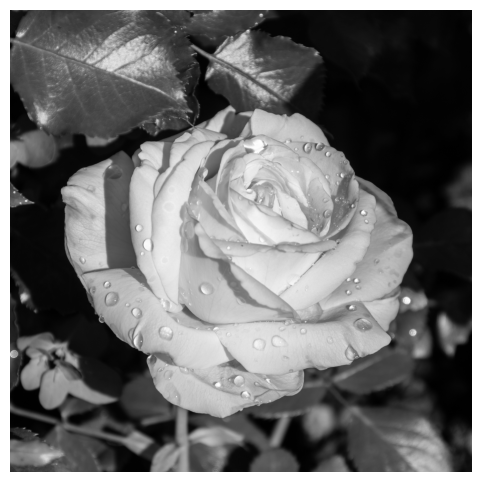

¡SVD calculada con éxito!

Dimensión de la matriz original: (3840, 3840)
Dimensión de U (vectores singulares izquierdos): (3840, 3840)
Dimensión de s (valores singulares en un vector 1D): (3840,)
Dimensión de Vt (vectores singulares derechos transpuestos): (3840, 3840)
El número total de valores singulares calculados es: 3840
Los 5 valores singulares más importantes son: [1711.46184704  366.94557967  328.68673423  295.95811317  213.39936312]
Construyendo aproximaciones Ak...
  -> Reconstruida matriz A_5 usando el 0.13% de los valores singulares.
  -> Reconstruida matriz A_20 usando el 0.52% de los valores singulares.
  -> Reconstruida matriz A_50 usando el 1.30% de los valores singulares.
  -> Reconstruida matriz A_100 usando el 2.60% de los valores singulares.
  -> Reconstruida matriz A_200 usando el 5.21% de los valores singulares.


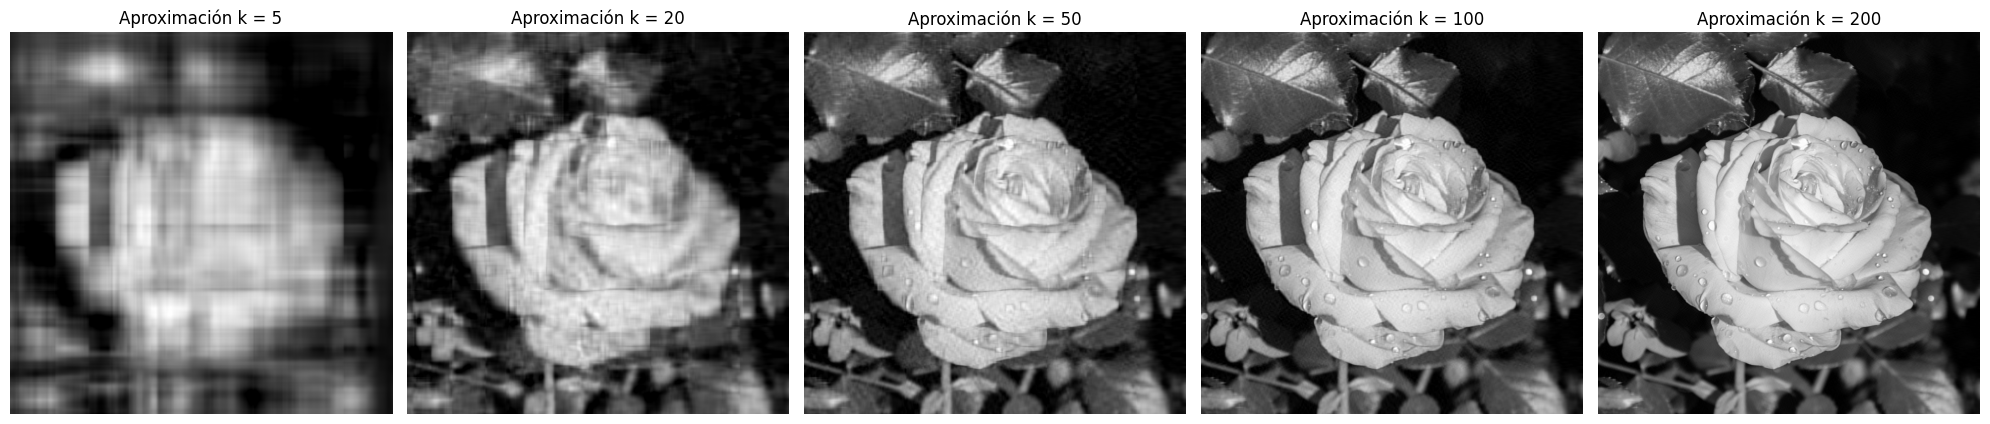

In [23]:
#lIBRERIAS:
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
from google.colab import files


#CODIGO:

#Carga de la imagen.
print("Por favor, selecciona la imagen desde tu computadora:")
img_color = None
try:
    archivos_cargados = files.upload()

    nombre_archivo = list(archivos_cargados.keys())[0]
    img_color = Image.open(io.BytesIO(archivos_cargados[nombre_archivo]))

    print(f"\n¡Imagen '{nombre_archivo}' cargada en memoria correctamente!")
    print(f"Formato original: {img_color.format} | Tamaño: {img_color.size}")
except IndexError:
    print("\nError: Cancelaste la subida de la imagen.")
except Exception as e:
    print(f"\nOcurrió un error al cargar la imagen: {e}")

#Finalización de la carga.

#Conversión a escala de grises y matriz de la misma.

img_gris = img_color.convert("L")

matriz_gris = np.array(img_gris) # Matriz de grises

#Mostrando la foto en  escala de grises:
plt.figure(figsize=(6, 6))
plt.imshow(matriz_gris, cmap='gray')
plt.axis('off')
plt.show()

#Cambio la matriz de decimales a flotante.

matriz_float = matriz_gris.astype(np.float64) / 255.0


# Calculo de la SVD.


U, s, Vt = np.linalg.svd(matriz_float, full_matrices=False)

print("¡SVD calculada con éxito!\n")
print(f"Dimensión de la matriz original: {matriz_float.shape}")
print(f"Dimensión de U (vectores singulares izquierdos): {U.shape}")
print(f"Dimensión de s (valores singulares en un vector 1D): {s.shape}")
print(f"Dimensión de Vt (vectores singulares derechos transpuestos): {Vt.shape}")

print(f"El número total de valores singulares calculados es: {len(s)}")

# Reconstruccion de la imagen.

valores_k = [5, 20, 50, 100, 200] #Valores solicitados.


fig, axes = plt.subplots(1, 5, figsize=(20, 5)) #Lienso donde se van a colocar las images

print("Construyendo aproximaciones Ak...")

for i, k in enumerate(valores_k):
    # 1. Tomamos las primeras k componentes de cada matriz
    Uk = U[:, :k]
    sk = s[:k]
    Vtk = Vt[:k, :]

    # 2. Reconstruimos la aproximación Ak multiplicando las matrices
    # Usamos np.diag(sk) para convertir el vector de k elementos en una matriz diagonal (k x k)
    # El operador @ realiza la multiplicación de matrices en NumPy
    Ak = Uk @ np.diag(sk) @ Vtk

    # 3. Opcional pero recomendado: Asegurar que los valores finales sigan entre 0.0 y 1.0
    # para evitar distorsiones visuales menores por errores de redondeo numérico
    Ak = np.clip(Ak, 0.0, 1.0)

    # 4. Graficar la aproximación Ak en su respectivo lugar
    axes[i].imshow(Ak, cmap='gray')
    axes[i].set_title(f"Aproximación k = {k}")
    axes[i].axis('off') # Ocultar los ejes numéricos

    # Imprimir un análisis rápido en texto para tu informe
    print(f"  -> Reconstruida matriz A_{k} usando el {((k / len(s)) * 100):.2f}% de los valores singulares.")

plt.tight_layout()
plt.show()